In [ ]:
from ResearchFramework.ResearchHandler import ResearchHandler
from ResearchFramework.simulation import *
import ResearchFramework.transforms as tf
from loader import load_fred_master
from macro_scores import score

RELOAD_DATA = False

if RELOAD_DATA:
    _ = load_fred_master()

temp = ResearchHandler("data/fred_master.csv")
scored = score(temp.data)
fred = ResearchHandler(scored)
fred.data.head()

,date,Headline_CPI,Core_CPI,PCE_Price_Index,Core_PCE,CPI_Food,CPI_Energy,UMich_Inflation_Expectations,Breakeven_Inflation_5Y,Breakeven_Inflation_10Y,...,Curve_10Y2Y_Lag_52w,Curve_10Y3M_Lag_52w,Breakeven_5Y_Lag_26w,Breakeven_5Y_Lag_52w,Home_Price_YoY_Lag_78w,Credit_Impulse_Lag_13w,Credit_Impulse_Lag_26w,FFR_Chg_52w,FFR_Chg_52w_Lag_52w,Sentiment_Lag_13w
0,1990-01-05,127.5,132.1,58.553,59.181,129.7,98.9,4.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-12,127.5,132.1,58.553,59.181,129.7,98.9,4.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-19,127.5,132.1,58.553,59.181,129.7,98.9,4.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-26,127.5,132.1,58.553,59.181,129.7,98.9,4.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-02-02,128.0,132.7,58.811,59.468,130.8,98.2,4.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
not_date = fred.data.select_dtypes(exclude=["datetime", "object"])

In [19]:
## make correlation matrix and pairs
corr_matrix = not_date.corr()
ordered_corr_pairs = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()

In [17]:
op = pd.DataFrame(ordered_corr_pairs, columns=["Correlation"])
op.index = pd.MultiIndex.from_tuples(op.index, names=["Var1", "Var2"])
op = op.reset_index()
op = op[op["Var1"] != op["Var2"]]
op

,Var1,Var2,Correlation
1,Unemployment_Rate,Unemployed_Approx,1.000000
2,Unemployed_Approx,Employment_Pressure,1.000000
3,PCE_Price_Index,Headline_CPI,0.999877
4,Core_CPI,Core_PCE,0.999690
5,Personal_Consumption_Expenditures,Nominal_GDP,0.999690
...,...,...,...
8858,Term_Premium_Proxy,SEP_PCE_Inflation_Median,-0.942582
8859,Term_Premium_Proxy,SEP_FFR_Med,-0.945331
8860,Labor_Force_Participation,Total_Reserves,-0.962630
8861,Debt_to_GDP,Labor_Force_Participation,-0.974629


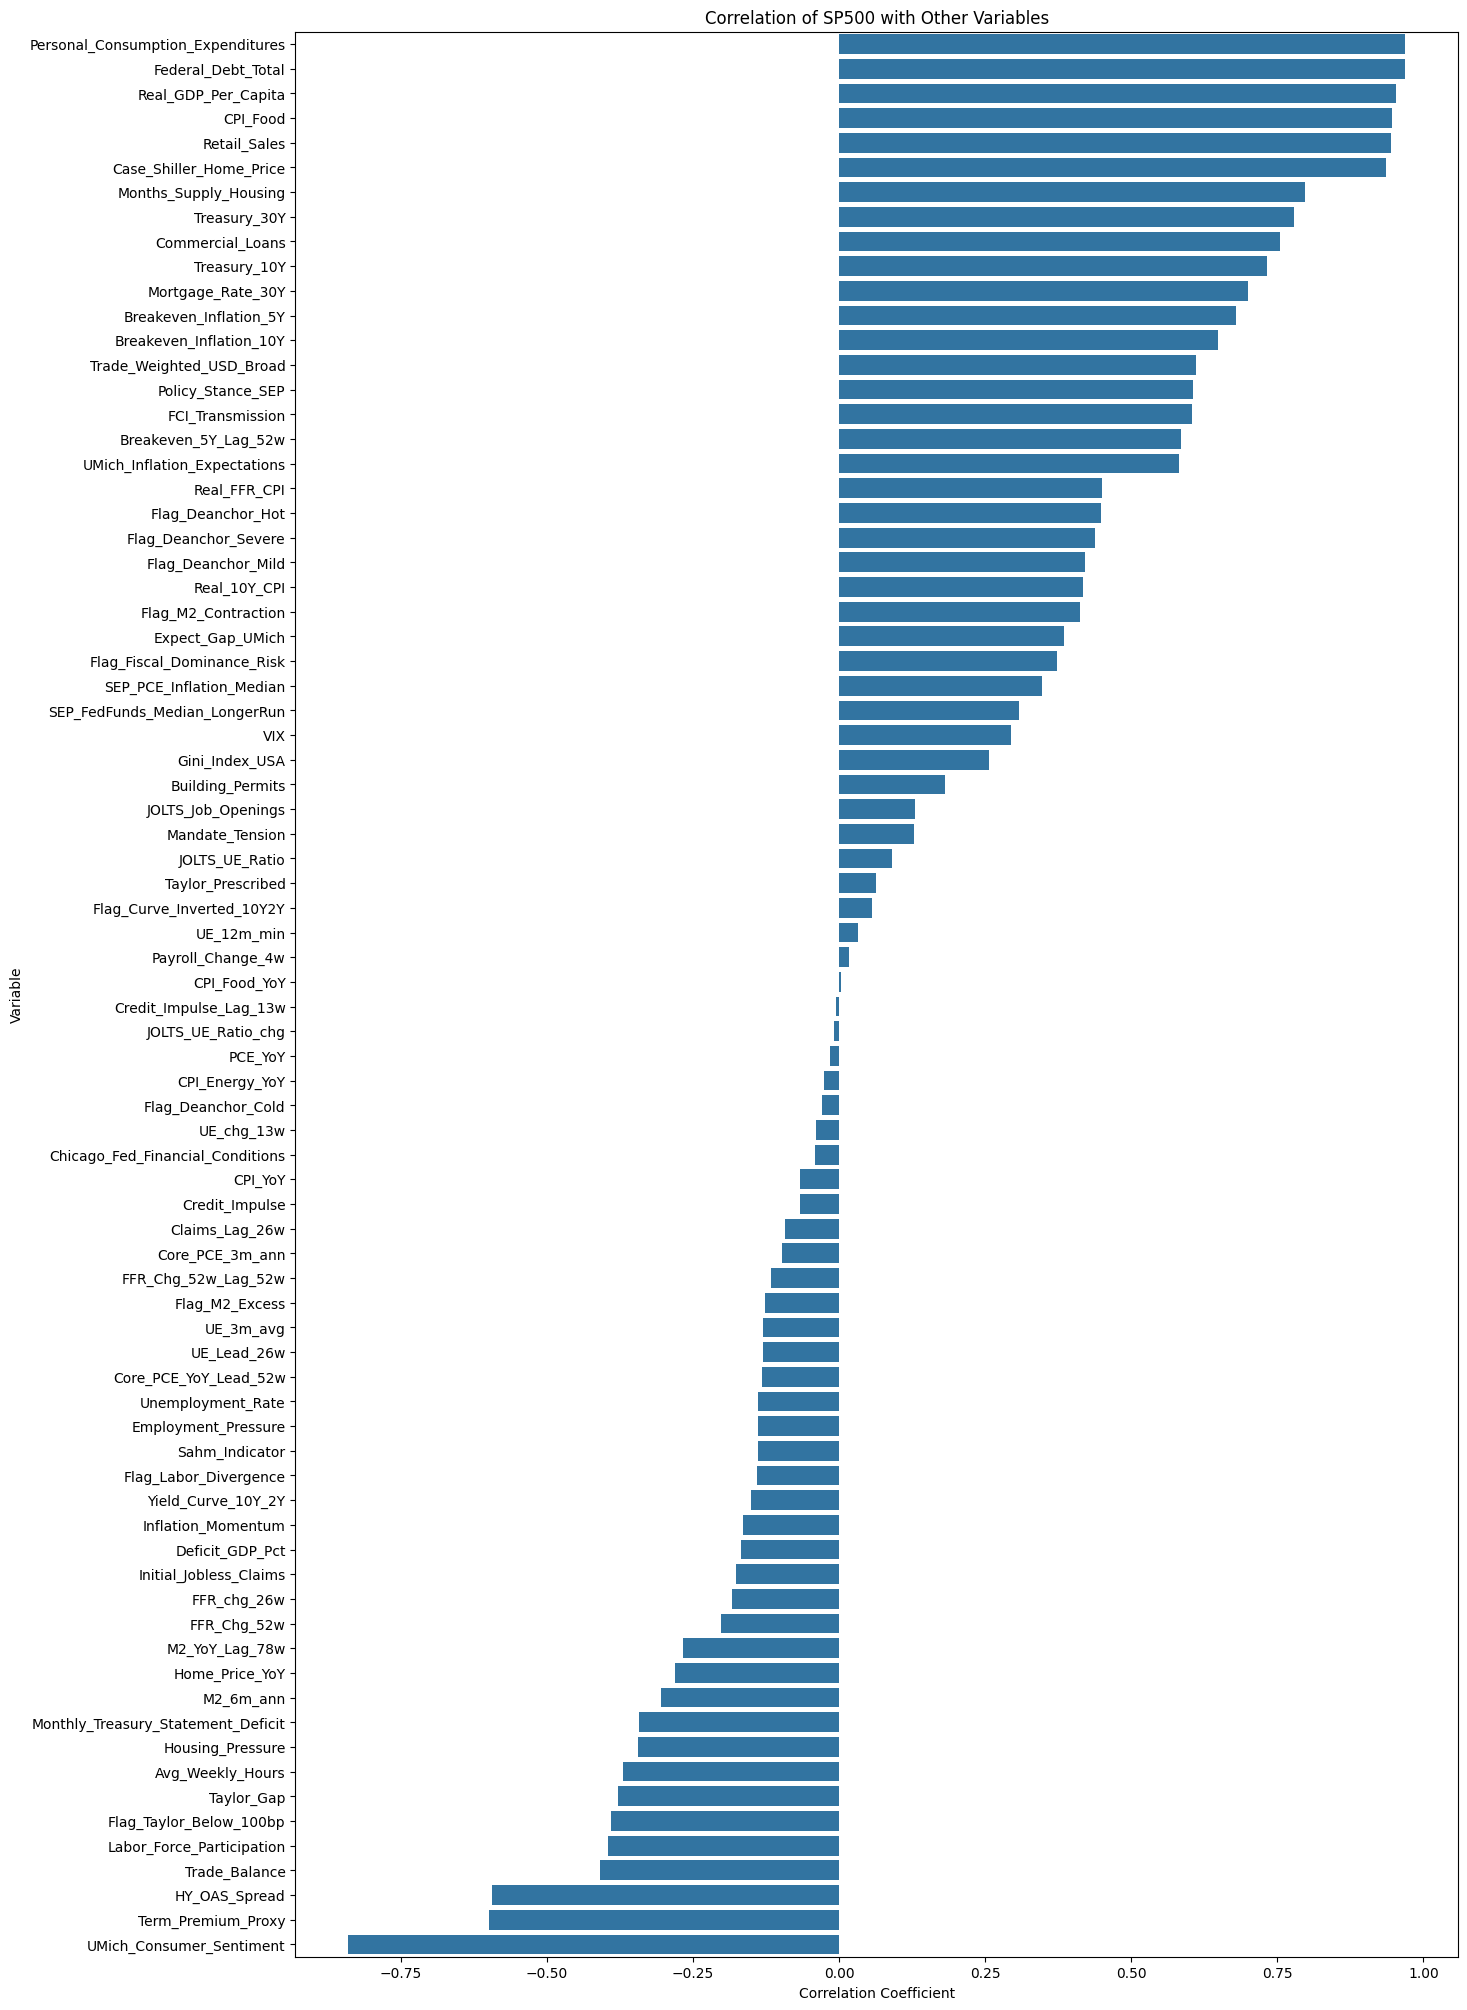

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
sp500_corrs = op[(op["Var1"] == "SP500")].sort_values(by="Correlation", ascending=False)

fig = plt.figure(figsize=(15, 25))
sns.barplot(x="Correlation", y="Var2", data=sp500_corrs)
plt.title("Correlation of SP500 with Other Variables")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")
plt.savefig("output_graphs/sp500_correlations.png")
fig;

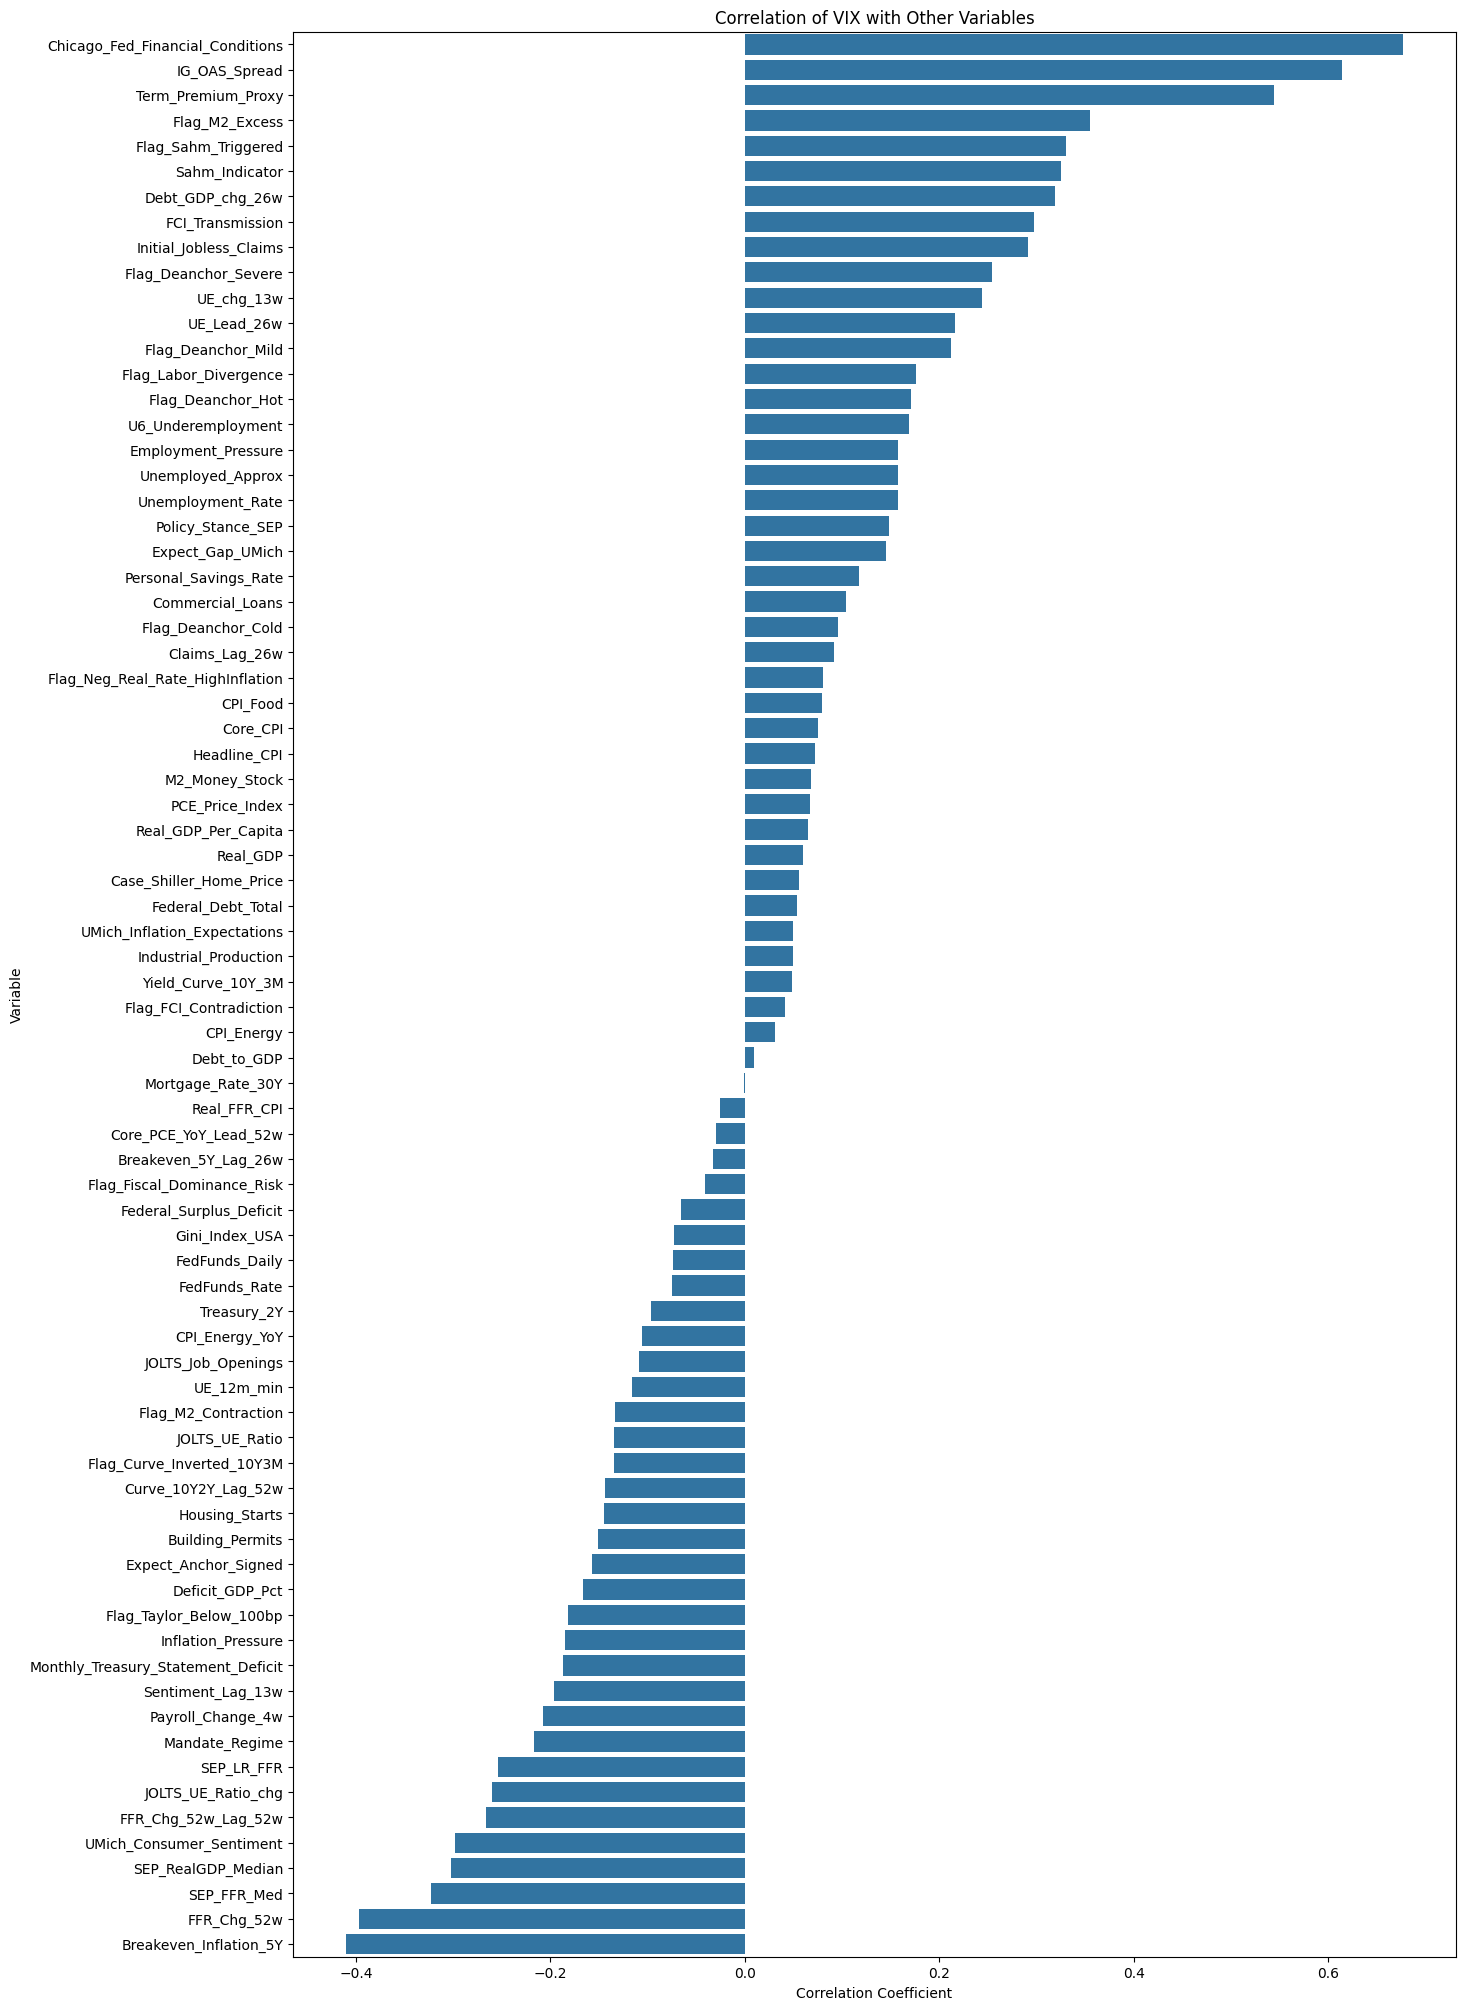

In [24]:
vix_corrs = op[(op["Var1"] == "VIX")].sort_values(by="Correlation", ascending=False)
fig = plt.figure(figsize=(15, 25))
sns.barplot(x="Correlation", y="Var2", data=vix_corrs)
plt.title("Correlation of VIX with Other Variables")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")
plt.savefig("output_graphs/vix_correlations.png")